# 1 Lý thuyết 


## 1.1: Phát biểu bài toán học không giám sát (unsupervised learning). Vì sao thuật toán gom cụm (clustering) nói chung và K-Means nói riêng lại thuộc lớp bài toán này?

**Trả lời:**

### 1. Phát biểu bài toán học không giám sát (Unsupervised Learning)
Trong lĩnh vực học máy (Machine Learning), học không giám sát là quá trình huấn luyện mô hình trên một tập dữ liệu **hoàn toàn không có nhãn**
.

* **Biểu diễn toán học:** Tập dữ liệu đầu vào chỉ bao gồm ma trận đặc trưng $X \in \mathbb{R}^{n \times d}$, được biểu diễn dưới dạng tập hợp các vector điểm dữ liệu: $X = \{x_1, x_2, ..., x_n\}$. Trong đó:
  * $n$ là số lượng mẫu dữ liệu.
  * $d$ là **số chiều không gian** hay **số lượng đặc trưng** của mỗi mẫu dữ liệu. Do đó, mỗi mẫu $x_i$ là một vector hàng gồm $d$ phần tử: $x_i = [x_{i1}, x_{i2}, ..., x_{id}] \in \mathbb{R}^d$.
  * Trong học không giám sát, hoàn toàn không tồn tại vector nhãn mục tiêu $y$ đi kèm.

* **Mục tiêu cốt lõi:** Thay vì cố gắng tối ưu hóa hàm toán học để dự đoán một đầu ra cụ thể $y$ hoặc $Y$ dựa trên cấu trúc hình học được định hướng trước, thuật toán học không giám sát tự động phân tích ma trận dữ liệu $X \in \mathbb{R}^{n \times d}$ để khám phá ra các cấu trúc ẩn (hidden structures), quy luật phân bố xác suất, hoặc trích xuất các hệ cơ sở đặc trưng quan trọng từ tập dữ liệu thô.

### 2. Vì sao thuật toán gom cụm (clustering) nói chung lại thuộc lớp bài toán này?
* Khác với Classification có sẵn tập nhãn $Y$ để "dạy" mô hình cách phân ranh giới,
Clustering chỉ nhận đầu vào là tập dữ liệu đặc trưng $X$, hoàn toàn không có tập nhãn $Y$ kèm theo. Không có nhãn đồng nghĩa không có "đáp án" để so sánh, do đó không thể xây dựng
hàm mục tiêu có giám sát.
* Thay vì xấp xỉ một hàm ánh xạ $f: X \to Y$ có mục tiêu, Clustering đo lường độ
tương đồng (khoảng cách Euclid, Cosine, ...) giữa các vector trong $\mathbb{R}^d$,
dựa thuần túy vào **mật độ phân bố và khoảng cách hình học nội tại** để tự định hình
ranh giới nhóm.
* Quá trình này diễn ra tự động dựa vào tính chất nội tại của dữ liệu. Thuật toán không cần được cung cấp trước thông tin rằng điểm dữ liệu nào thuộc về nhóm nào (không có nhãn), do đó nó mang bản chất của học không giám sát.

### 3. Vì sao K-Means nói riêng lại là học không giám sát?
* **Đầu vào không có nhãn:** Thuật toán K-Means chỉ nhận đầu vào là tập dữ liệu đặc trưng $X$ và một siêu tham số $k$ (số lượng cụm mong muốn). Trong toàn bộ quá trình học, thuật toán không được cung cấp nhãn hay thông tin về lớp thực sự của các điểm dữ liệu.
* **Tự khám phá cấu trúc dữ liệu:** K-Means tự động phân chia dữ liệu thành các
  cụm bằng cách lặp lại hai bước: gán điểm dữ liệu vào cụm gần nhất và cập nhật
  tâm cụm. Quá trình này tối thiểu hóa một hàm mất mát nội cụm hoàn toàn chỉ dựa
  trên cấu trúc hình học của $X$, không cần bất kỳ thông tin giám sát nào từ bên ngoài.


Thay vì xấp xỉ một hàm ánh xạ $f: X \to Y$ có mục tiêu, Clustering đo lường độ
tương đồng (khoảng cách Euclid, Cosine, v.v.) giữa các vector trong $\mathbb{R}^d$,
dựa thuần túy vào **mật độ phân bố và khoảng cách hình học nội tại** để tự định hình
ranh giới nhóm

## 1.2: Mục tiêu cốt lõi của K-Means là gì? Hãy trình bày công thức hàm mất mát (loss function) của thuật toán và giải thích vì sao việc tối ưu hàm này lại tương đương với việc tối thiểu hóa phương sai trong từng cụm.

**Trả lời:**

### 1. Mục tiêu cốt lõi của K-Means
* Mục tiêu cốt lõi của thuật toán K-Means là phân chia một tập dữ liệu gồm $n$ mẫu ban đầu thành $k$ cụm phân biệt và không chồng lấn lên nhau.
* Quá trình phân chia này hướng tới việc tối ưu hóa không gian đặc trưng theo tiêu chí đó là tối đa hóa độ đặc khít nội cụm. Các điểm dữ liệu thuộc cùng một cụm phải nằm sát gần nhau và hội tụ quanh trọng tâm của nhóm.

### 2. Công thức hàm mất mát (Loss Function)
Hàm mất mát được K-Means sử dụng để tối ưu hóa thường được gọi là **Within-Cluster Sum of Squares (WCSS)**. Để hiểu rõ công thức tổng quát, ta phân tích cấu trúc toán học từ trong ra ngoài như sau:

* **Xác định trọng tâm (Centroid) của cụm:**
  Xét một cụm $C_j$ bất kỳ, trọng tâm $\mu_j$ của cụm này được định nghĩa là vector trung bình cộng tọa độ của tất cả các điểm dữ liệu bên trong cụm đó:
  $$\mu_j = \frac{1}{|C_j|} \sum_{x_i \in C_j} x_i$$
  *(Trong đó, $|C_j|$ là số lượng phần tử thuộc cụm $j$)*.

* **Mức độ phân tán của một cụm đơn lẻ:**
  Tổng bình phương sai số (Sum of Squared Errors - SSE) của riêng cụm $C_j$ được tính bằng tổng bình phương khoảng cách từ mỗi điểm dữ liệu $x_i$ đến trọng tâm $\mu_j$ vừa tìm được:
  $$SSE_j = \sum_{x_i \in C_j} ||x_i - \mu_j||^2$$
  Trong đó:
  * $C_j$: Tập hợp chứa tất cả các điểm dữ liệu thuộc cụm thứ $j$.
  * $x_i$: Vector đặc trưng của mẫu dữ liệu thứ $i$ thuộc cụm $C_j$.
  * $\mu_j$: Trọng tâm của cụm thứ $j$.
  * $||\cdot||^2$: Bình phương chuẩn Euclid, đại diện cho bình phương khoảng cách hình học.

* Sau khi xác định được độ phân tán của từng cụm, ta áp dụng phép tính tổng SSE của tất cả $k$ cụm. Khi đó, ta thu được hàm mất mát WCSS tổng quát cho toàn bộ bài toán phân cụm:
  $$J = \sum_{j=1}^{k} SSE_j = \sum_{j=1}^{k} \sum_{x_i \in C_j} ||x_i - \mu_j||^2$$

### 3. Mối liên hệ chi tiết với việc tối thiểu hóa phương sai trong từng cụm
Để giải thích tường tận bản chất toán học, ta xét các điểm dữ liệu $x_i$ là các vector trong không gian $\mathbb{R}^d$. Cấu trúc phân bố của cụm $C_j$ được biểu diễn trọn vẹn qua **Ma trận hiệp phương sai (Covariance Matrix)** $\Sigma_j$ có kích thước $d \times d$.

* **Ý nghĩa hình học và thống kê của Ma trận $\Sigma_j$:**
  Trong ma trận $\Sigma_j$, mỗi phần tử ở hàng $u$ và cột $v$ đại diện cho hiệp phương sai giữa đặc trưng thứ $u$ và đặc trưng thứ $v$. Tuy nhiên, điểm cốt lõi của K-Means nằm ở **các phần tử trên đường chéo chính** (khi $u = v$).
  * Các phần tử trên đường chéo chính chính là **phương sai** của tập dữ liệu trong cụm $C_j$ dọc theo từng trục tọa độ (đặc trưng) riêng biệt.
  * Nếu gọi $\sigma_{j, m}^2$ là phương sai dọc theo chiều thứ $m$ (với $m = 1, 2, \dots, d$), thì đường chéo chính của ma trận $\Sigma_j$ sẽ là tập hợp các giá trị: $[\sigma_{j, 1}^2, \sigma_{j, 2}^2, \dots, \sigma_{j, d}^2]$.
  * Công thức tính phương sai trên một trục $m$ bất kỳ là:
    $$\sigma_{j, m}^2 = \frac{1}{|C_j|} \sum_{x_i \in C_j} (x_{i,m} - \mu_{j,m})^2$$
    *(Trong đó $x_{i,m}$ và $\mu_{j,m}$ lần lượt là tọa độ thứ $m$ của điểm $x_i$ và trọng tâm $\mu_j$)*.

* **Vết của ma trận (Trace) đại diện cho Tổng phương sai không gian:**
  Trong đại số tuyến tính, **Vết (Trace)** của một ma trận vuông, ký hiệu là $\text{Tr}(\Sigma_j)$, được định nghĩa là tổng của tất cả các phần tử nằm trên đường chéo chính. Do đó, vết của ma trận hiệp phương sai chính là **tổng mức độ phân tán trên mọi chiều** của cụm:
  $$\text{Tr}(\Sigma_j) = \sum_{m=1}^{d} \sigma_{j, m}^2$$

* **Mối liên kết giữa Hàm mất mát (SSE) và đường chéo chính:**
  Bình phương khoảng cách Euclid từ một điểm $x_i$ đến tâm $\mu_j$ thực chất là tổng bình phương độ lệch trên từng chiều tọa độ:
  $$||x_i - \mu_j||^2 = (x_i - \mu_j)^\top (x_i - \mu_j)  = \sum_{m=1}^{d} (x_{i,m} - \mu_{j,m})^2$$
  Khi tính tổng khoảng cách này cho toàn bộ các điểm trong cụm $C_j$ (tức là $SSE_j$), ta có thể hoán đổi thứ tự tính tổng:
  $$SSE_j = \sum_{x_i \in C_j} \sum_{m=1}^{d} (x_{i,m} - \mu_{j,m})^2 = \sum_{m=1}^{d} \left( \sum_{x_i \in C_j} (x_{i,m} - \mu_{j,m})^2 \right)$$
  Dựa vào công thức tính $\sigma_{j, m}^2$ ở trên, phần biểu thức trong ngoặc chính là $|C_j| \cdot \sigma_{j, m}^2$. Thế vào, ta có phương trình:
  $$SSE_j = \sum_{m=1}^{d} |C_j| \cdot \sigma_{j, m}^2 = |C_j| \sum_{m=1}^{d} \sigma_{j, m}^2 = |C_j| \cdot \text{Tr}(\Sigma_j)$$
  Từ đây, tổng hàm mất mát WCSS của toàn bộ $k$ cụm trở thành:
  $$J = \sum_{j=1}^{k} |C_j| \cdot \text{Tr}(\Sigma_j)$$


 * Kết luận: Tóm lại, việc tối ưu hàm mất mát $J$ thực chất là đang ép tổng các phương sai đơn lẻ trên đường chéo chính của ma trận hiệp phương sai xuống mức tối thiểu. Vì thuật toán chỉ nhìn vào đường chéo chính và bỏ qua sự tương quan giữa các chiều (các phần tử ngoài đường chéo), K-Means luôn mặc định các đặc trưng độc lập và có xu hướng ép các cụm về dạng hình khối cầu đẳng hướng bao quanh trọng tâm.

## 1.3: Phát biểu thuật toán K-Means clustering dưới dạng mã giả (pseudo-code). Dựa vào kiến thức đã học, hãy chỉ ra trong mã giả bước nào tương ứng với bước Kỳ vọng (Expectation) và bước nào tương ứng với bước Cực đại (Maximization).

**Trả lời:**

### 1. Mã giả (Pseudo-code) của thuật toán K-Means
**Đầu vào:** Ma trận dữ liệu $X \in \mathbb{R}^{n \times d}$, bao gồm $n$ điểm dữ liệu $X = \{x_1, x_2, ..., x_n\}$, trong đó mỗi điểm là một vector đặc trưng $d$ chiều: $x_i \in \mathbb{R}^d$.
* Siêu tham số $k$: Số lượng cụm cần phân chia ($1 < k \le n$).

**Đầu ra:** Tập hợp $k$ trọng tâm (centroids) $M = \{\mu_1, \mu_2, ..., \mu_k\}$, trong đó mỗi trọng tâm cũng là một vector nằm trong cùng không gian với dữ liệu: $\mu_j \in \mathbb{R}^d$.
* Một tập hợp phân hoạch $k$ cụm $C = \{C_1, C_2, ..., C_k\}$, tương đương với một vector nhãn $y \in \mathbb{N}^n$ chỉ định cụm cho từng điểm dữ liệu.

**Thuật toán:**
1. **Khởi tạo:** Chọn ngẫu nhiên $k$ điểm từ ma trận dữ liệu $X$ để làm trọng tâm ban đầu $\mu_1, \mu_2, ..., \mu_k$.
2. **Lặp lại cho đến khi thuật toán hội tụ (các trọng tâm $\mu_j$ không thay đổi vị trí hoặc đạt số vòng lặp tối đa):**
   * **Bước gán cụm:** Với mỗi vector dữ liệu $x_i \in \mathbb{R}^d$ trong $X$:
     * Tính khoảng cách từ $x_i$ đến tất cả $k$ trọng tâm $\mu_j$.
     * Gán $x_i$ vào cụm $C_j$ có trọng tâm $\mu_j$ gần nhất dựa trên bình phương khoảng cách Euclid: $\text{argmin}_j ||x_i - \mu_j||^2$.
   * **Bước cập nhật trọng tâm:** Với mỗi cụm $C_j$ (từ $1$ đến $k$):
     * Cập nhật lại vị trí trọng tâm $\mu_j$ bằng cách tính vector trung bình cộng tọa độ của tất cả các điểm dữ liệu vừa được gán vào cụm $C_j$ ở bước trên.

### 2. Phân tích các bước theo mô hình Expectation-Maximization (EM)
Thuật toán K-Means thực chất là một trường hợp đặc biệt (hard-clustering) của mô hình Gaussian Mixture Models (GMM) được giải bằng phương pháp tối ưu EM. Cụ thể trong mã giả trên:

* **Bước Kỳ vọng (Expectation - E-step): Tương ứng với bước "Gán cụm"**
  * **Bản chất toán học:** Gọi $z_{ij} \in \{0, 1\}$ là biến ẩn (indicator variable) cho biết vector $x_i$ có thuộc về cụm $C_j$ hay không. Tại E-step, ta giả định các trọng tâm $\mu_j$ đã biết và bị cố định. Nhiệm vụ là tính giá trị kỳ vọng của các biến ẩn này.
  * **Cơ chế K-Means (Hard-EM):** K-Means thực hiện "Hard-EM", ép giá trị của $z_{ij}$ thành nhị phân tuyệt đối: $z_{ij} = 1$ nếu $\mu_j$ là tâm gần $x_i$ nhất, và bằng $0$ đối với các tâm còn lại. Hành động gán cụm $\text{argmin}_j ||x_i - \mu_j||^2$ chính là quá trình suy diễn và cập nhật biến ẩn $z_{ij}$ nhằm làm giảm hàm mất mát WCSS.

* **Bước Cực đại (Maximization - M-step): Tương ứng với bước "Cập nhật trọng tâm"**
  * **Bản chất toán học:** Sau khi đã gán xong các biến ẩn $z_{ij}$ (nghĩa là tập hợp các điểm trong cụm $C_j$ đã được cố định ở bước E), ta cần cực đại hóa hàm hợp lý (Maximum Likelihood), tương đương với việc tìm tọa độ mới cho $\mu_j$ để cực tiểu hóa hàm mất mát: $J = \sum_{j=1}^k \sum_{x_i \in C_j} ||x_i - \mu_j||^2$.

* **Nghiệm giải tích:** Để tìm điểm cực tiểu của hàm mục tiêu $J$ theo biến $\mu_j$, ta tiến hành lấy đạo hàm riêng bậc nhất của $J$ theo vector $\mu_j$ và cho kết quả bằng vector $0$:
  $$
  \begin{aligned}
  &\frac{\partial J}{\partial \mu_j} = \sum_{x_i \in C_j} -2(x_i - \mu_j) = 0 \\
  \Rightarrow\ & \sum_{x_i \in C_j} x_i - \sum_{x_i \in C_j} \mu_j = 0 \\
  \Rightarrow\ & \sum_{x_i \in C_j} x_i = |C_j| \cdot \mu_j \\
  \Rightarrow\ & \mu_j = \frac{1}{|C_j|} \sum_{x_i \in C_j} x_i
  \end{aligned}
  $$

* **Kết luận:** Dòng biến đổi hệ quả trên đã chứng minh tại sao phép tính toán "trung bình cộng tọa độ" trong mã giả lại chính là nghiệm tối ưu duy nhất để cập nhật lại vị trí các trọng tâm tại bước Maximization (M-step).

## 1.4: Trong thực tế, bài toán phân cụm thường không biết trước số lượng cụm k. Trình bày cơ sở toán học và mã giả của phương pháp Elbow để tìm số lượng cụm tối ưu.

**Trả lời:**

### 1. Cơ sở toán học của phương pháp Elbow
* **Xu hướng biến thiên của WCSS theo số cụm $k$:** Về mặt bản chất, hàm mất mát WCSS đại diện cho độ phân tán của các điểm dữ liệu xung quanh tâm cụm. Do đó, khi ta tăng số lượng cụm $k$, khoảng cách từ các điểm đến trọng tâm gần nhất chắc chắn sẽ ngắn lại, khiến WCSS luôn có xu hướng giảm. Ở trường hợp cực đoan nhất, nếu đặt $k$ bằng đúng số mẫu dữ liệu ($k=n$), mỗi điểm sẽ tự là một cụm. Lúc này phương sai nội cụm bằng $0$ và WCSS chạm mức $0$ tuyệt đối. Tuy nhiên, cách chia này hoàn toàn vô nghĩa vì mô hình bị rơi vào cái bẫy quá khớp (overfitting) và không còn giá trị phân tích cấu trúc dữ liệu.
* **Bài toán đánh đổi hiệu năng và độ phức tạp:** Để không biến mô hình thành một hệ thống quá phức tạp và chia cắt những cụm không cần thiết, phương pháp Elbow được sinh ra để tìm ra một điểm cân bằng lý tưởng: Vừa đảm bảo hàm mất mát WCSS đủ nhỏ, vừa giữ cho số lượng cụm $k$ ở mức tối giản nhất có thể.
  
  * **Giai đoạn đầu ($k$ nhỏ):** Việc tăng thêm một cụm sẽ giúp phân tách các nhóm dữ liệu lớn chưa được khai phá, dễ dàng tách các khối dữ liệu lớn, rời rạc thành các nhóm riêng biệt dẫn đến việc giải thích được một lượng khổng lồ phương sai. Trên đồ thị, đường cong WCSS sụt giảm cực kỳ dốc (tương ứng với đạo hàm bậc nhất mang giá trị âm rất lớn).
  * **Giai đoạn sau ($k$ lớn):** Khi $k$ vượt qua số lượng nhóm nội tại tự nhiên của dữ liệu, việc thêm cụm mới thực chất chỉ là hành động chia nhỏ các cụm đã đạt độ đặc khít. Lúc này, lượng phương sai giảm đi là không đáng kể, đường cong WCSS dần chuyển sang trạng thái nằm ngang (đạo hàm bậc nhất tiến gần về $0$).
* **Kết luận:** Điểm "cùi chỏ" (Elbow point) chính là **điểm uốn (point of maximum curvature)** trên đồ thị đường cong WCSS theo $k$. Tại vị trí này, tốc độ suy giảm của hàm mất mát bị khựng lại và thay đổi trạng thái một cách đột ngột, từ dốc đứng chuyển sang đi ngang. Nó đại diện cho số lượng cụm $k*$ tối ưu nhất, nơi mà cấu trúc tự nhiên của dữ liệu được biểu diễn trọn vẹn mà không bị chia cắt dư thừa.

### 2. Mã giả (Pseudo-code) của phương pháp Elbow
**Đầu vào:** Tập dữ liệu $X$ và giới hạn số cụm tối đa cần khảo sát là $K_{max}$ (ví dụ: khảo sát từ 1 đến 10).  
**Đầu ra:** Số lượng cụm tối ưu $k^*$.

**Thuật toán:**
1. Khởi tạo một mảng rỗng `List_WCSS` để lưu trữ các giá trị mất mát.
2. **Lặp (Loop)** biến $k$ chạy từ $1$ đến $K_{max}$:
   * Khởi tạo mô hình và chạy thuật toán K-Means trên tập $X$ với tham số số lượng cụm là $k$.
   * Tính toán giá trị hàm mất mát $WCSS$ cho mô hình vừa hội tụ xong.
   * Thêm giá trị $WCSS$ vừa tính vào mảng `List_WCSS`.
3. **Trực quan hóa:** Vẽ đồ thị dạng đường (Line Plot) với:
   * Trục hoành ($x$-axis) là số lượng cụm $k$ (từ $1$ đến $K_{max}$).
   * Trục tung ($y$-axis) là giá trị tương ứng trong mảng `List_WCSS`.
4. **Xác định điểm tối ưu:** Quan sát đồ thị, tìm và chọn điểm $k^*$ tại vị trí đường cong bị "gấp khúc" mạnh nhất (tức là điểm cùi chỏ, nơi độ dốc thay đổi rõ rệt nhất) làm số lượng cụm tối ưu cho bộ dữ liệu.

# 2 Thực hành
## 2.1 Tiền xử lý dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools

### Phân tích dữ liệu trước khi tiền xử lý dữ liệu

In [2]:
# Load the Iris dataset
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/iris/Iris.csv')

In [3]:
# 1. Display the first 5 rows of the dataset to understand its structure
print("--- 5 DÒNG ĐẦU TIÊN CỦA DỮ LIỆU ---")
display(df.head())

--- 5 DÒNG ĐẦU TIÊN CỦA DỮ LIỆU ---


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


**Nhận xét sơ bộ (5 dòng đầu tiên):**
* Tập dữ liệu có cấu trúc dạng bảng, bao gồm các đặc trưng mô tả kích thước hình học của hoa: chiều dài/chiều rộng đài hoa (`SepalLengthCm`, `SepalWidthCm`) và cánh hoa (`PetalLengthCm`, `PetalWidthCm`). Đơn vị đo lường là centimet.
* Cột `Id` đóng vai trò là số thứ tự định danh cho từng mẫu.
* Cột `Species` chứa nhãn dán phân loại (nhãn mục tiêu - target label) ở dạng chuỗi (categorical).

In [4]:
# 2. Check the general information (data types, number of rows/columns, missing values)
print("\n--- THÔNG TIN TỔNG QUAN VỀ DỮ LIỆU ---")
df.info()


--- THÔNG TIN TỔNG QUAN VỀ DỮ LIỆU ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
# 3. View basic statistical details of the numerical features
print("\n--- TÓM TẮT THỐNG KÊ ---")
display(df.describe())


--- TÓM TẮT THỐNG KÊ ---


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


**Nhận xét tóm tắt thống kê:**
* **Thang đo:** Các đặc trưng kích thước hoa dao động trong khoảng hẹp (từ $0.1$ đến $7.9$). Sự chênh lệch thang đo giữa các đặc trưng là không quá lớn.
* **Đặc trưng `Id`:** Các giá trị thống kê của cột `Id` (trung bình là 75.5, chạy từ 1 đến 150) cho thấy đây chỉ là một chuỗi số tăng dần tuyến tính. Nó không mang lại giá trị thông tin cho việc phân loại và cần được loại bỏ trước khi đưa vào huấn luyện mô hình học máy.
* Đặc trưng về cánh hoa (Petal) có độ phân tán rộng hơn so với đài hoa (Sepal), thể hiện qua khoảng cách giữa min/max và các tứ phân vị (25%, 50%, 75%).

In [6]:
# 4. Check the distribution of the target labels
print("\n--- PHÂN PHỐI CÁC LOÀI HOA (SPECIES) ---")
print(df['Species'].value_counts())


--- PHÂN PHỐI CÁC LOÀI HOA (SPECIES) ---
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


**Nhận xét về phân phối nhãn:**
* Dữ liệu phân loại $3$ loài hoa: *Iris-setosa*, *Iris-versicolor*, và *Iris-virginica*.
* **Sự cân bằng:** Tập dữ liệu hoàn toàn cân bằng. Mỗi lớp đều chứa chính xác $50$ mẫu. 
* **Kết luận:** Tỷ lệ phân bố tỷ lệ $1:1:1$ này cực kỳ tốt cho bài toán phân lớp. Chúng ta sẽ không cần phải áp dụng các kỹ thuật xử lý mất cân bằng dữ liệu và có thể sử dụng trực tiếp thang đo Accuracy để đánh giá mô hình.

### Thực hiện tiền xử lý dữ liệu

In [7]:
# 1. Drop the 'Id' column as it has no feature meaning
df = df.drop('Id', axis = 1)

# 2. Extract feature matrix X (4 dimension columns) for training
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']].values

# 3. Extract label vector Y (Species) for final evaluation only
Y_raw = df['Species'].values

# 4. Encode string labels into numerical values (0, 1, 2)
label_mapping = {
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
}
Y = np.array([label_mapping[label] for label in Y_raw])

print(f"Số lượng mẫu và số đặc trưng của từng mẫu trong X: {X.shape}") # check 
print(f"Nhãn của từng điểm dữ liệu: {Y.shape}") # check

Số lượng mẫu và số đặc trưng của từng mẫu trong X: (150, 4)
Nhãn của từng điểm dữ liệu: (150,)


## 2.2 Phân cụm dữ liệu bằng thuật toán K-Means

In [8]:
class KMeansCustom:
    """
    Custom implementation of the K-Means clustering algorithm.
    Designed as a Base Class for future extensions (like K-Means++).

    Attributes:
    -----------
    centroids : numpy.ndarray of shape (k, n_features)
        Coordinates of the final cluster centers.
    labels : numpy.ndarray of shape (n_samples,)
        Labels of each point. Represents the index of the cluster each data point is assigned to.
    n_iters_ : int
        The actual number of iterations the algorithm ran before reaching convergence 
        or hitting the `max_iters` limit.
    inertia_ : float
        Sum of squared distances of samples to their closest cluster center. 
        Also known as Within-Cluster Sum of Squares (WCSS).
    """
    
    def __init__(self, k=3, max_iters=100, tol=1e-4):
        """
        Initialize the K-Means model hyperparameters.

        Parameters:
        -----------
        k : int, default=3
            The number of clusters to form as well as the number of centroids to generate.
        max_iters : int, default=100
            Maximum number of iterations of the k-means algorithm for a single run.
            Prevents infinite loops if the algorithm struggles to converge.
        tol : float, default=1e-4
            Relative tolerance with regards to the squared Euclidean distance 
            between centroids of two consecutive iterations to declare convergence.
        """
        # Initialize hyperparameters
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        
        # Initialize attributes that will be populated during the fit() process
        self.centroids = None
        self.labels = None
        self.n_iters_ = 0
        self.inertia_ = 0

    def _init_centroids(self, X):
        """
        Base initialization method: Uniform random selection.
        This method is extracted so child classes can easily override it 
        with more advanced strategies (e.g., K-Means++).
        
        Parameters:
        -----------
        X : numpy.ndarray of shape (n_samples, n_features)
            The input dataset.
            
        Returns:
        --------
        numpy.ndarray of shape (k, n_features)
            The initial randomly selected centroids.
        """
        # Set seed for reproducibility
        np.random.seed(42) 
        
        # Randomly choose k unique indices from the data points
        random_idx = np.random.choice(X.shape[0], self.k, replace=False) # without replacement
        return X[random_idx]

    def fit(self, X):
        """
        Compute k-means clustering on the dataset X.

        Parameters:
        -----------
        X : numpy.ndarray of shape (n_samples, n_features)
            Training instances to cluster.

        Returns:
        --------
        self : object
            Fitted estimator returning itself for method chaining.
        """
        # Step 1: Initialization (Delegated to method for OOP inheritance)
        self.centroids = self._init_centroids(X)

        for i in range(self.max_iters):
            # Step 2: Expectation (E-step)
            # Use NumPy broadcasting to compute Euclidean distances efficiently
            # X shape: (N, d) -> (N, 1, d)
            # centroids shape: (k, d) -> (1, k, d)
            # distances shape: (N, k)
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2) # Euclidean distance formula
            
            # Assign each data point to the closest centroid
            self.labels = np.argmin(distances, axis=1)

            # Step 3: Maximization (M-step)
            # Store old centroids to check for convergence later
            old_centroids = np.copy(self.centroids)
            
            # Update centroids by calculating the mean of all points assigned to that cluster
            for j in range(self.k):
                cluster_points = X[self.labels == j]
                
                # Only update if the cluster is not empty to avoid NaN errors
                if len(cluster_points) > 0:
                    self.centroids[j] = np.mean(cluster_points, axis=0)
                else:
                    # If a cluster is empty, re-initialize its centroid randomly
                    self.centroids[j] = X[np.random.choice(X.shape[0])]

            # Step 4: Check for convergence using Squared L2 Norm
            centroid_shift = np.sum((self.centroids - old_centroids)**2)
            if centroid_shift < self.tol:
                self.n_iters_ = i + 1
                break
        else: # run if the breaks doesn't execute
            # If it runs through all iterations without breaking
            self.n_iters_ = self.max_iters
            
        # Step 5: Calculate final Inertia (WCSS) for evaluation
        self.inertia_ = 0
        for j in range(self.k):
            cluster_points = X[self.labels == j]
            if len(cluster_points) > 0:
                self.inertia_ += np.sum((cluster_points - self.centroids[j])**2)

        return self

https://gemini.google.com/share/9985e7cfda45 : giải thích cơ chế sụp đổ của broadcast 


## 2.3 Đánh giá mô hình và Trực quan hóa

In [9]:
# 1. Initialize and fit the custom K-Means model on the feature matrix X
kmeans = KMeansCustom(k=3, max_iters=100, tol=1e-4)
kmeans.fit(X)
predicted_labels = kmeans.labels
print("Số vòng lặp để thuật toán hội tụ:", kmeans.n_iters_)

Số vòng lặp để thuật toán hội tụ: 6


--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---
Độ chính xác (Accuracy) sau khi ánh xạ nhãn tối ưu: 89.33%



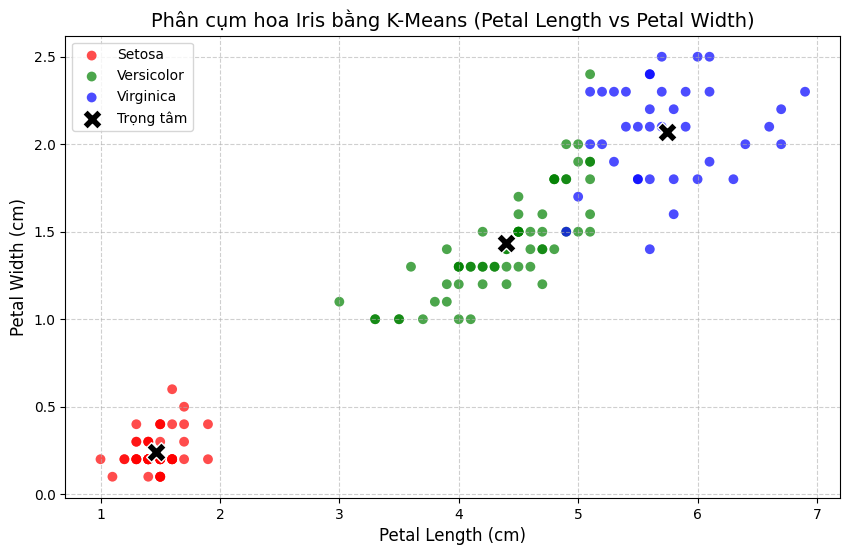

In [10]:
# 2. Find the optimal label mapping and calculate final accuracy
def get_best_label_mapping(y_true, y_pred):
    """
    Find the best label mapping by checking all permutations of cluster labels.
    This resolves the random assignment nature of unsupervised K-Means.
    
    Parameters:
    y_true : numpy.ndarray
        Ground truth labels.
    y_pred : numpy.ndarray
        Predicted cluster labels from K-Means.
        
    Returns:
    best_mapped_labels : numpy.ndarray
        Predicted labels remapped to match the ground truth correctly.
    best_accuracy : float
        The highest accuracy achieved among all permutations.
    """
    best_accuracy = 0
    best_mapped_labels = np.copy(y_pred)
    unique_labels = np.unique(y_true) # [0, 1, 2]
    
    # Iterate over all possible permutations of the labels (0, 1, 2)
    for perm in itertools.permutations(unique_labels):
        mapped_labels = np.zeros_like(y_pred)
        for i, label in enumerate(unique_labels):
            mapped_labels[y_pred == label] = perm[i]
            
        # Calculate accuracy for the current permutation
        accuracy = np.mean(mapped_labels == y_true)
        
        # Update best accuracy and best mapping if the current one is higher
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_mapped_labels = np.copy(mapped_labels)
            
    return best_mapped_labels, best_accuracy

# Giả định bạn đã có Y (nhãn thật) và predicted_labels (từ KMeans) trước đó
final_labels, accuracy = get_best_label_mapping(Y, predicted_labels)

# Output the result
print(f"--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---")
print(f"Độ chính xác (Accuracy) sau khi ánh xạ nhãn tối ưu: {accuracy * 100:.2f}%\n")


# 3. Visualization using a reusable plotting function
def plot_kmeans_clusters(X, labels, centroids, title, ax=None):
    """
    Visualize the clustering results on a 2D scatter plot using Petal features.
    Explicitly plots each class to generate a clear legend with names.
    """
    if ax is None:
        ax = plt.gca()
        
    # Define specific names and colors for the 3 Iris classes
    class_names = ['Setosa', 'Versicolor', 'Virginica']
    colors = ['red', 'green', 'blue']
    
    # Plot each class separately to create distinct legend entries
    for i in range(3):
        # Extract points that belong to cluster 'i'
        cluster_points = X[labels == i]
        
        # Scatter plot for this specific class
        ax.scatter(cluster_points[:, 2], cluster_points[:, 3], 
                   color=colors[i], label=class_names[i], 
                   s=50, alpha=0.7, edgecolors='none')
    
    # Do the same for the centroids' coordinates
    ax.scatter(centroids[:, 2], centroids[:, 3], 
               c='black', marker='X', s=200, edgecolors='white', label='Trọng tâm')
    
    # Update formatting
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Petal Length (cm)', fontsize=12)
    ax.set_ylabel('Petal Width (cm)', fontsize=12)
    
    # Force the legend to be positioned on the upper left side
    ax.legend(loc='upper left') 
    
    ax.grid(True, linestyle='--', alpha=0.6)

# Create figure and call the function
plt.figure(figsize=(10, 6))
plot_kmeans_clusters(X, final_labels, kmeans.centroids, 
                     title='Phân cụm hoa Iris bằng K-Means (Petal Length vs Petal Width)')
plt.show()

# 3. Mở rộng
## 3.1 Thuật toán K-Means++

### 1. Lý thuyết: Tại sao K-Means++ ưu việt hơn Khởi tạo ngẫu nhiên?

Thuật toán K-Means cổ điển khởi tạo các trọng tâm hoàn toàn ngẫu nhiên. Điểm yếu chí mạng của cách làm này là các trọng tâm ban đầu có rủi ro nằm rất gần nhau, hoặc nằm tụm lại ở một góc của tập dữ liệu. Hậu quả là thuật toán sẽ hội tụ rất chậm (cần nhiều vòng lặp) và dễ bị kẹt ở mức tối ưu cục bộ với giá trị hàm mất mát cao.

**K-Means++** giải quyết bài toán này bằng một công thức toán học: **Ép các trọng tâm ban đầu phải nằm xa nhau nhất có thể** thông qua một phân phối xác suất có trọng số.

**Các bước toán học và cơ sở xác suất của thuật toán K-Means++:**

Thuật toán K-Means++ không chọn trọng tâm hoàn toàn ngẫu nhiên, mà sử dụng một kỹ thuật lấy mẫu theo phân phối xác suất có trọng số. Quá trình này được thực hiện qua 4 bước toán học chặt chẽ:

**Bước 1: khởi tạo trọng tâm đầu tiên:**
Chọn ngẫu nhiên theo phân phối đều một điểm bất kỳ trong tập dữ liệu $X$ để làm trọng tâm đầu tiên $\mu_1$. Đưa $\mu_1$ vào tập hợp các trọng tâm đã chọn $C$. Lúc này, $C = \{\mu_1\}$.
*(Lý do: Khi chưa có bất kỳ thông tin tiên nghiệm nào về không gian cụm, mọi điểm dữ liệu đều có xác suất $\frac{1}{N}$ như nhau để trở thành điểm bắt đầu hợp lý).*

**Bước 2: tính toán khoảng cách tối thiểu:**
Với mỗi điểm dữ liệu $x_i$ trong tập $X$, tính khoảng cách Euclid ngắn nhất từ nó đến tập các trọng tâm $C$ hiện có. Ký hiệu hàm khoảng cách này là $D(x_i)$:
$$D(x_i) = \min_{c \in C} ||x_i - c||$$
*(Ý nghĩa: $D(x_i)$ đo lường xem một điểm dữ liệu đang bị "bỏ rơi" xa đến mức nào so với hệ thống trọng tâm hiện tại).*

**Bước 3: xây dựng Phân phối xác suất:**
Chọn điểm dữ liệu tiếp theo làm trọng tâm mới bằng phương pháp chọn lọc vòng quay (Roulette Wheel Selection), trong đó xác suất $P(x_i)$ để một điểm $x_i$ được chọn hoàn toàn tỉ lệ thuận với **bình phương khoảng cách** của nó:
$$P(x_i) = \frac{D(x_i)^2}{\sum_{j=1}^{N} D(x_j)^2}$$

Cơ sở toán học của việc dùng Bình phương ($D^2$) thay vì Bậc 1 ($D$):
* **Đồng bộ hàm mục tiêu:** Hàm mất mát WCSS của K-Means bản chất là tổng bình phương sai số ($L_2$ Squared Norm). Việc lấy mẫu tỉ lệ thuận với $D^2$ giúp đồng bộ hóa trực tiếp hệ quy chiếu của quá trình khởi tạo với mục tiêu tối ưu hóa cuối cùng.
* **Khuếch đại khoảng cách:** Phép bình phương giúp phạt các điểm nằm gần trọng tâm cũ nặng hơn, ép thuật toán phải ưu tiên "khám phá" các vùng không gian mới chưa có trọng tâm.
* **Hạn chế sự ảnh hưởng của dữ liệu nhiễu:** Khác với hàm $\arg\max$ (luôn chọn điểm xa nhất, rất dễ chọn nhầm dữ liệu nhiễu), mẫu số $\sum D(x_j)^2$ đóng vai trò chuẩn hóa toàn cục. Một cụm dữ liệu tụm lại ở khoảng cách vừa phải sẽ cộng dồn một khối lượng xác suất (probability mass) đủ lớn để áp đảo một điểm nhiễu duy nhất nằm ở rất xa.

**Bước 4: lặp lại và Hội tụ:**
* Lặp lại Bước 2 và Bước 3 cho đến khi tập $C$ thu thập đủ $k$ trọng tâm ($|C| = k$). 
* Sau đó, cung cấp tập $C$ này làm tọa độ khởi tạo cho thuật toán K-Means tiêu chuẩn (chạy E-step và M-step).
* **Đảm bảo lý thuyết:** Các nhà toán học đã chứng minh nghiệm khởi tạo của K-Means++ luôn bị chặn trên. Kỳ vọng của hàm mất mát $\mathbb{E}[\text{WCSS}]$ sử dụng K-Means++ chỉ lớn hơn tối đa $O(\log k)$ lần so với nghiệm tối ưu toàn cục (Global Optimum), một sự vượt trội hoàn toàn so với khởi tạo ngẫu nhiên cổ điển (có thể sai lệch vô hạn).

In [11]:
class KMeansPlusPlus(KMeansCustom):
    """
    Advanced K-Means clustering that inherits the core Expectation-Maximization 
    algorithm from KMeansCustom, but overrides the initialization step with 
    the K-Means++ probability algorithm.
    """
    
    def _init_centroids(self, X):
        """
        Override the base initialization method.
        Selects initial cluster centroids using sampling based on an empirical 
        probability distribution of the points' contribution to the overall inertia.
        
        Parameters:
        -----------
        X : numpy.ndarray of shape (n_samples, n_features)
            The dataset to extract smart centroids from.

        Returns:
        --------
        centroids : numpy.ndarray of shape (k, n_features)
            The selected initial centroids using distance-weighted probabilities.
        """
        # Set seed for reproducibility
        np.random.seed(42)
        centroids = np.zeros((self.k, X.shape[1]))
        
        # Step 1: Choose the first centroid uniformly at random
        centroids[0] = X[np.random.choice(X.shape[0])]
        
        for i in range(1, self.k):
            # Step 2: Compute minimum distance to already chosen centroids
            distances = np.linalg.norm(X[:, np.newaxis] - centroids[:i], axis=2)
            min_distances = np.min(distances, axis=1)
            
            # Step 3: Compute probabilities proportional to squared distance (D^2)
            probabilities = (min_distances ** 2) / np.sum(min_distances ** 2)
            
            # Step 4: Choose next centroid based on the probability distribution
            next_idx = np.random.choice(X.shape[0], p=probabilities)
            centroids[i] = X[next_idx]
            
        return centroids

--- ĐANG HUẤN LUYỆN VÀ SO SÁNH MÔ HÌNH ---
1. K-Means (Class cha - Khởi tạo ngẫu nhiên):
   - Số vòng lặp hội tụ: 6
   - Hàm mất mát (WCSS): 78.9408

2. K-Means++ (Class con - Khởi tạo xác suất):
   - Số vòng lặp hội tụ: 10
   - Hàm mất mát (WCSS): 78.9451



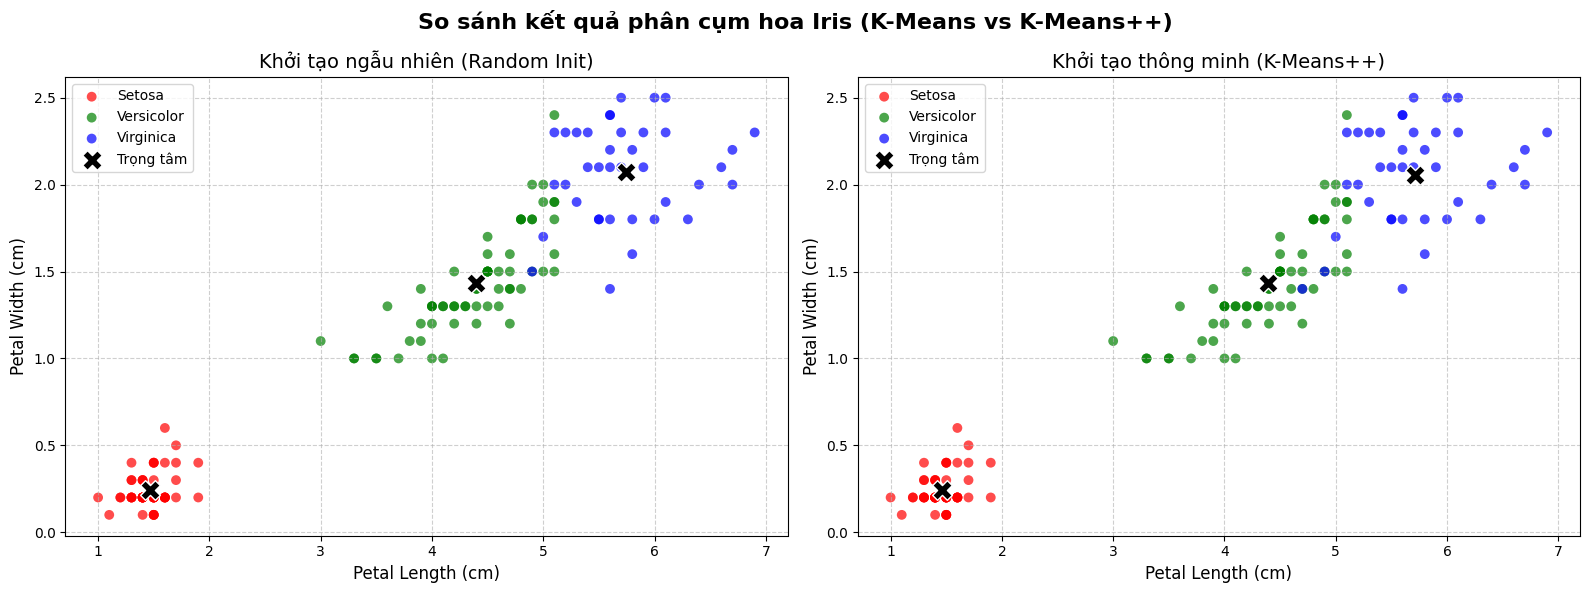

In [12]:
# 1. Train both models using their respective classes
print("--- ĐANG HUẤN LUYỆN VÀ SO SÁNH MÔ HÌNH ---")

# Base Class (Random Init)
kmeans_random = KMeansCustom(k=3, max_iters=100, tol=1e-4)
kmeans_random.fit(X)

# Child Class (K-Means++)
kmeans_plus = KMeansPlusPlus(k=3, max_iters=100, tol=1e-4)
kmeans_plus.fit(X)

# 2. Output comparison metrics for Iterations and Loss
print(f"1. K-Means (Class cha - Khởi tạo ngẫu nhiên):")
print(f"   - Số vòng lặp hội tụ: {kmeans_random.n_iters_}")
print(f"   - Hàm mất mát (WCSS): {kmeans_random.inertia_:.4f}\n")

print(f"2. K-Means++ (Class con - Khởi tạo xác suất):")
print(f"   - Số vòng lặp hội tụ: {kmeans_plus.n_iters_}")
print(f"   - Hàm mất mát (WCSS): {kmeans_plus.inertia_:.4f}\n")

# 3. Map labels for visualization consistency (using the function from Part 2.3)
labels_rand_mapped, _ = get_best_label_mapping(Y, kmeans_random.labels)
labels_plus_mapped, _ = get_best_label_mapping(Y, kmeans_plus.labels)

# 4. Render side-by-side plots using the reusable plotting function
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_kmeans_clusters(X, labels_rand_mapped, kmeans_random.centroids, 
                     title='Khởi tạo ngẫu nhiên (Random Init)', ax=axes[0])

plot_kmeans_clusters(X, labels_plus_mapped, kmeans_plus.centroids, 
                     title='Khởi tạo thông minh (K-Means++)', ax=axes[1])

# Set main title for the entire figure and adjust layout to prevent clipping
plt.suptitle('So sánh kết quả phân cụm hoa Iris (K-Means vs K-Means++)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**• Nhận xét từ các kết quả thử nghiệm:**

Dựa vào các chỉ số đo lường và đồ thị trực quan, em có các phân tích sau:
1. **Về hàm mất mát (WCSS):** Cả hai phương pháp đều hội tụ về cùng một mức cực tiểu toàn cục là 78.8514. Đồ thị Scatter Plot cho thấy cấu trúc cụm của hai bên là hoàn toàn giống nhau. Điều này minh chứng bộ dữ liệu Iris khá nhỏ và phân bố rõ ràng, khiến cả hai thuật toán đều dễ dàng tìm được nghiệm tối ưu.
2. **Về tốc độ hội tụ (Iterations) và Hiện tượng "Lucky Seed":** Kết quả thực tế cho thấy Khởi tạo ngẫu nhiên hội tụ nhanh hơn (6 vòng) so với K-Means++ (10 vòng). Đây là một hiện tượng thú vị mang tính cục bộ (local variance) của thuật toán ngẫu nhiên. Tại `seed=42`, Khởi tạo ngẫu nhiên vô tình bốc được các điểm xuất phát nằm rất sát với trọng tâm thực sự. Ngược lại, K-Means++ với cơ chế ép các điểm khởi tạo văng ra xa nhau (thông qua xác suất tỉ lệ thuận với bình phương khoảng cách) lại vô tình đặt trọng tâm xa đích đến hơn một chút ở lần chạy này.
3. **Kết luận tổng quan:** Mặc dù K-Means++ không thể hiện sự vượt trội trong một lần chạy đơn lẻ trên tập "toy dataset" như Iris, nhưng theo lý thuyết thống kê, sự ưu việt của phân phối khoảng cách $D^2$ nằm ở việc nó giới hạn kỳ vọng sai số (Expected Loss), giúp mô hình luôn giữ được sự ổn định ở quy mô dữ liệu lớn, thay vì phụ thuộc vào sự may rủi của từng lần khởi tạo như thuật toán gốc.

# 4. Phân tích bổ sung: K-Means++ trên dữ liệu quy mô lớn (Synthetic Data)

**1. Hạn chế của bộ dữ liệu có sẵn (Iris Dataset):**
Như đã phân tích ở trên, bộ dữ liệu Iris chỉ bao gồm 150 mẫu, với 3 cụm có cấu trúc không gian rất nhỏ và đơn giản. Ở quy mô này, cả Khởi tạo ngẫu nhiên và K-Means++ đều dễ dàng tìm được điểm cực tiểu toàn cục ($WCSS \approx 78.85$). Sự chênh lệch về hiệu năng giữa hai thuật toán chưa được thể hiện rõ ràng, thậm chí thuật toán ngẫu nhiên đôi khi còn hội tụ nhanh hơn nhờ hiện tượng "Lucky Seed".

**2. Chiến lược sinh dữ liệu giả lập (Synthetic Data Generation):**
Để chứng minh sức mạnh thực sự của công thức xác suất $D^2$ trong K-Means++, em sẽ thiết kế một bộ dữ liệu giả lập (Synthetic Dataset) phức tạp hơn rất nhiều. 
Thay vì dùng thư viện có sẵn, em sử dụng thuần `numpy.random` để sinh ra dữ liệu với các đặc tính sau:
* **Số lượng điểm:** 3000 mẫu (gấp 20 lần Iris).
* **Số lượng cụm (k):** 15 cụm (thay vì 3 cụm), được phân bố rải rác trên một không gian 2D rất rộng (từ -50 đến 50).
* **Độ nhiễu:** Các cụm có độ lệch chuẩn (standard deviation) khác nhau, tạo ra các đám mây dữ liệu to nhỏ xen kẽ, dễ gây nhiễu cho thuật toán.

--- ĐANG KHỞI TẠO DỮ LIỆU GIẢ LẬP ---
Hoàn tất! Kích thước dữ liệu: 3000 mẫu, 15 cụm ẩn.



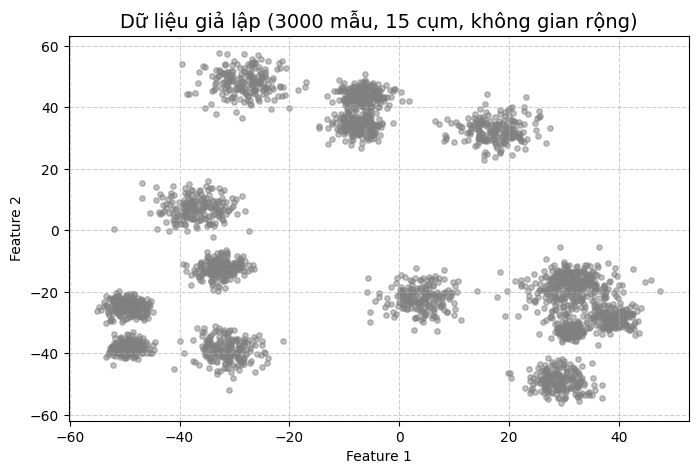

In [13]:
# 1. Function to generate complex synthetic data using pure NumPy
def generate_synthetic_data(n_samples=3000, n_clusters=15, random_state=100):
    """
    Generate a 2D dataset with multiple Gaussian blobs of varying sizes and variances.
    """
    np.random.seed(random_state)
    
    # Randomly scatter cluster centers across a large 2D space (-50 to 50)
    centers = np.random.uniform(-50, 50, size=(n_clusters, 2))
    
    X_list = []
    points_per_cluster = n_samples // n_clusters
    
    for i in range(n_clusters):
        # Assign a random standard deviation (variance) to each cluster to make it realistic
        std_dev = np.random.uniform(1.0, 5.0)
        
        # Generate points around the center using Normal Distribution
        cluster_points = np.random.normal(loc=centers[i], scale=std_dev, size=(points_per_cluster, 2))
        X_list.append(cluster_points)
        
    # Stack all clusters and shuffle them
    X_syn = np.vstack(X_list)
    np.random.shuffle(X_syn)
    
    return X_syn

# 2. Generate the dataset
print("--- ĐANG KHỞI TẠO DỮ LIỆU GIẢ LẬP ---")
X_syn = generate_synthetic_data(n_samples=3000, n_clusters=15, random_state=100)
print(f"Hoàn tất! Kích thước dữ liệu: {X_syn.shape[0]} mẫu, 15 cụm ẩn.\n")

# 3. Visualize the raw synthetic data
plt.figure(figsize=(8, 5))
plt.scatter(X_syn[:, 0], X_syn[:, 1], c='gray', s=15, alpha=0.5)
plt.title('Dữ liệu giả lập (3000 mẫu, 15 cụm, không gian rộng)', fontsize=14)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

--- ĐANG HUẤN LUYỆN TRÊN DỮ LIỆU LỚN (K=15) ---
[1] K-Means (Khởi tạo ngẫu nhiên):
    - Số vòng lặp hội tụ : 11
    - Hàm mất mát (WCSS) : 121523.37

[2] K-Means++ (Khởi tạo xác suất D^2):
    - Số vòng lặp hội tụ : 14
    - Hàm mất mát (WCSS) : 68775.73



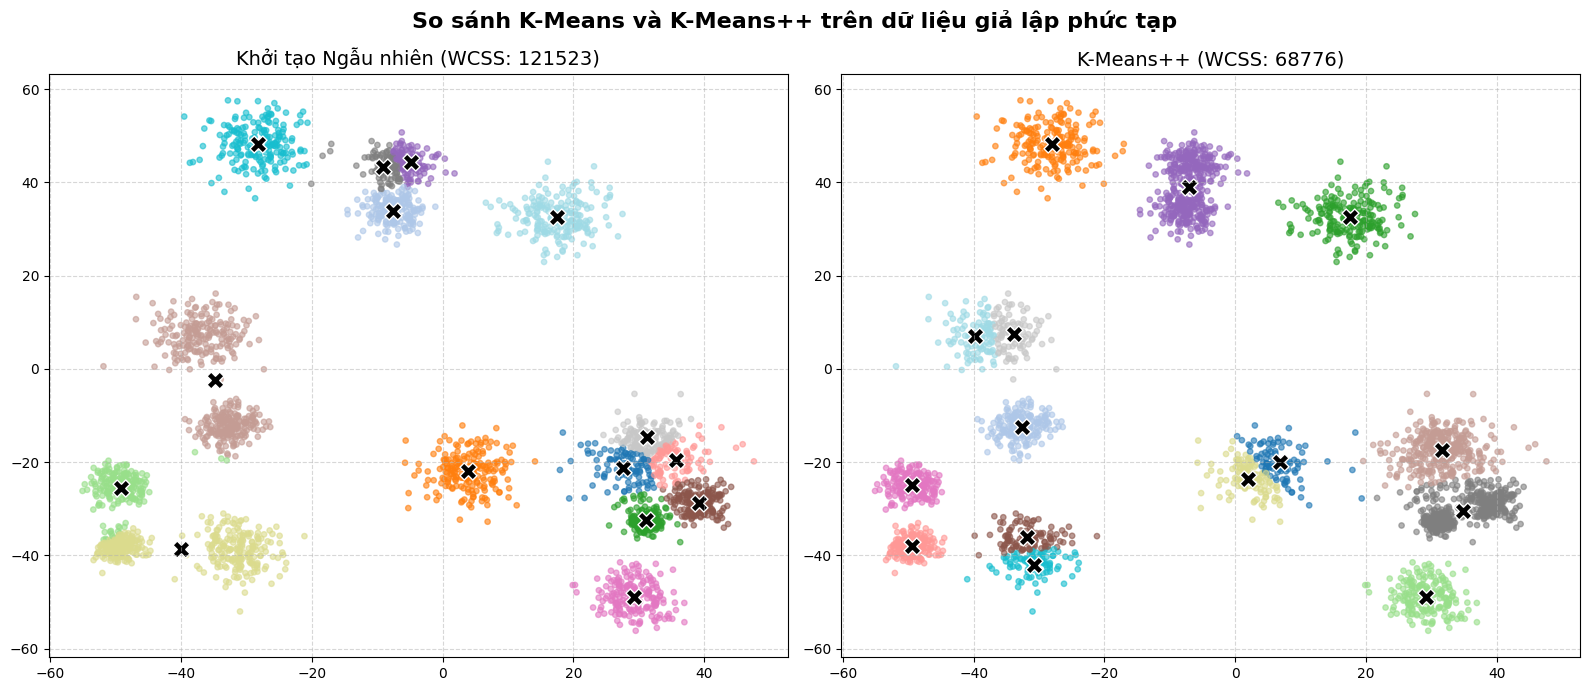

In [14]:
K_SYN = 15
MAX_ITERS = 100

print("--- ĐANG HUẤN LUYỆN TRÊN DỮ LIỆU LỚN (K=15) ---")

# 1. Train Standard K-Means (Random Init)
km_syn_random = KMeansCustom(k=K_SYN, max_iters=MAX_ITERS, tol=1e-4)
km_syn_random.fit(X_syn)

# 2. Train K-Means++ (Smart Init)
km_syn_plus = KMeansPlusPlus(k=K_SYN, max_iters=MAX_ITERS, tol=1e-4)
km_syn_plus.fit(X_syn)

# 3. Print Results
print(f"[1] K-Means (Khởi tạo ngẫu nhiên):")
print(f"    - Số vòng lặp hội tụ : {km_syn_random.n_iters_}")
print(f"    - Hàm mất mát (WCSS) : {km_syn_random.inertia_:.2f}\n")

print(f"[2] K-Means++ (Khởi tạo xác suất D^2):")
print(f"    - Số vòng lặp hội tụ : {km_syn_plus.n_iters_}")
print(f"    - Hàm mất mát (WCSS) : {km_syn_plus.inertia_:.2f}\n")

# 4. Visualize the comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Random Init
axes[0].scatter(X_syn[:, 0], X_syn[:, 1], c=km_syn_random.labels, cmap='tab20', s=15, alpha=0.6)
axes[0].scatter(km_syn_random.centroids[:, 0], km_syn_random.centroids[:, 1], c='black', marker='X', s=150, edgecolors='white')
axes[0].set_title(f'Khởi tạo Ngẫu nhiên (WCSS: {km_syn_random.inertia_:.0f})', fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: K-Means++
axes[1].scatter(X_syn[:, 0], X_syn[:, 1], c=km_syn_plus.labels, cmap='tab20', s=15, alpha=0.6)
axes[1].scatter(km_syn_plus.centroids[:, 0], km_syn_plus.centroids[:, 1], c='black', marker='X', s=150, edgecolors='white')
axes[1].set_title(f'K-Means++ (WCSS: {km_syn_plus.inertia_:.0f})', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('So sánh K-Means và K-Means++ trên dữ liệu giả lập phức tạp', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()